# Temperature Causal Exploration

本 notebook 专门研究 **temperature** 对 judge 行为的因果影响。

核心问题：
- 温度升高会如何影响 `agreement`、`error_rate`、`consistency_1flip`？
- 相比基准温度 `0.01`，其他温度的 ATE 分别是多少？
- 高温（>=1.5）相对于低温（<=0.5）整体影响多大？
- 温度的效应是否因 `model_group`、`judge_type` 等条件而异？

本 notebook 主要包含四类分析：
1. 温度因果图（Temperature DAG）
2. 相对基准温度 `0.01` 的 pairwise ATE
3. 高温 vs 低温 的整体 ATE
4. 基于 g-computation 的温度 dose-response 曲线与子群体异质性

In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
np.random.seed(42)


def resolve_path(candidates: list[str]) -> Path:
    for cand in candidates:
        p = Path(cand)
        if p.exists():
            return p.resolve()
    raise FileNotFoundError(f"Could not resolve any of: {candidates}")


ARTIFACT_DIR = resolve_path(["output", "../output"])
ROW_DATA_PATH = resolve_path([
    "output/combined_judge_dataset_qwen_gemma.csv",
    "../output/combined_judge_dataset_qwen_gemma.csv",
])
CONS_DATA_PATH = resolve_path([
    "output/combined_judge_consistency_qwen_gemma.csv",
    "../output/combined_judge_consistency_qwen_gemma.csv",
])

row_df = pd.read_csv(ROW_DATA_PATH)
cons_df = pd.read_csv(CONS_DATA_PATH)

row_df = row_df.copy()
cons_df = cons_df.copy()
row_df["temperature"] = pd.to_numeric(row_df["temperature"], errors="coerce")
cons_df["temperature"] = pd.to_numeric(cons_df["temperature"], errors="coerce")
row_df["agreement"] = pd.to_numeric(row_df["agreement"], errors="coerce")
row_df["error_rate"] = pd.to_numeric(row_df["error_rate"], errors="coerce")
cons_df["consistency_1flip"] = pd.to_numeric(cons_df["consistency_1flip"], errors="coerce")

TEMP_VALUES = sorted(row_df["temperature"].dropna().unique().tolist())
CONTROL_COLS = ["model_group", "dataset", "judge_type", "prompt_variant"]
MATCH_KEYS_ROW = CONTROL_COLS + ["question_id", "repeat_id"]
MATCH_KEYS_CONS = CONTROL_COLS + ["question_id"]
OUTCOME_LABELS = {
    "agreement": "Agreement",
    "error_rate": "Error Rate",
    "consistency_1flip": "Consistency (1-flip)",
}
OUTCOME_COLORS = {
    "agreement": "#c44e52",
    "error_rate": "#4c72b0",
    "consistency_1flip": "#55a868",
}


def _ci95(est: float, se: float) -> tuple[float, float]:
    return float(est - 1.96 * se), float(est + 1.96 * se)


def _build_design_matrix(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    tmp = data[columns].copy()
    tmp = pd.get_dummies(tmp, columns=[c for c in columns if str(tmp[c].dtype) == "object"], drop_first=True)
    return tmp.apply(pd.to_numeric, errors="coerce").fillna(0.0)


def format_temp(x: float) -> str:
    return f"{float(x):.2f}"


print("Row data path :", ROW_DATA_PATH)
print("Cons data path:", CONS_DATA_PATH)
print("Artifact dir  :", ARTIFACT_DIR)
print("Temperatures  :", TEMP_VALUES)
print("Row count     :", len(row_df))
print("Cons count    :", len(cons_df))
display(row_df[["model_group", "dataset", "judge_type", "prompt_variant", "temperature", "agreement", "error_rate"]].head(3))
display(cons_df[["model_group", "dataset", "judge_type", "prompt_variant", "temperature", "consistency_1flip"]].head(3))

Row data path : /home/snt/projects_lujun/LLMJudgeTempCausal/output/combined_judge_dataset_qwen_gemma.csv
Cons data path: /home/snt/projects_lujun/LLMJudgeTempCausal/output/combined_judge_consistency_qwen_gemma.csv
Artifact dir  : /home/snt/projects_lujun/LLMJudgeTempCausal/output
Temperatures  : [0.01, 0.5, 1.0, 1.5, 2.0, 3.0]
Row count     : 360000
Cons count    : 36000


,model_group,dataset,judge_type,prompt_variant,temperature,agreement,error_rate
0,qwen,mt_bench_human_judgments,pairwise,baseline,0.01,0.0,0.0
1,qwen,mt_bench_human_judgments,pairwise,baseline,0.01,0.0,0.0
2,qwen,mt_bench_human_judgments,pairwise,baseline,0.01,1.0,0.0


,model_group,dataset,judge_type,prompt_variant,temperature,consistency_1flip
0,gemma,mmlu_pro,pairwise,baseline,0.01,1.0
1,gemma,mmlu_pro,pairwise,baseline,0.01,1.0
2,gemma,mmlu_pro,pairwise,baseline,0.01,1.0


## Temperature DAG

在这个 notebook 里，**temperature** 是处理变量。

调整集合：
- `model_group`
- `dataset`
- `judge_type`
- `prompt_variant`

这些变量既可能影响采样设计，也会影响最终 outcome，因此用于 backdoor adjustment。

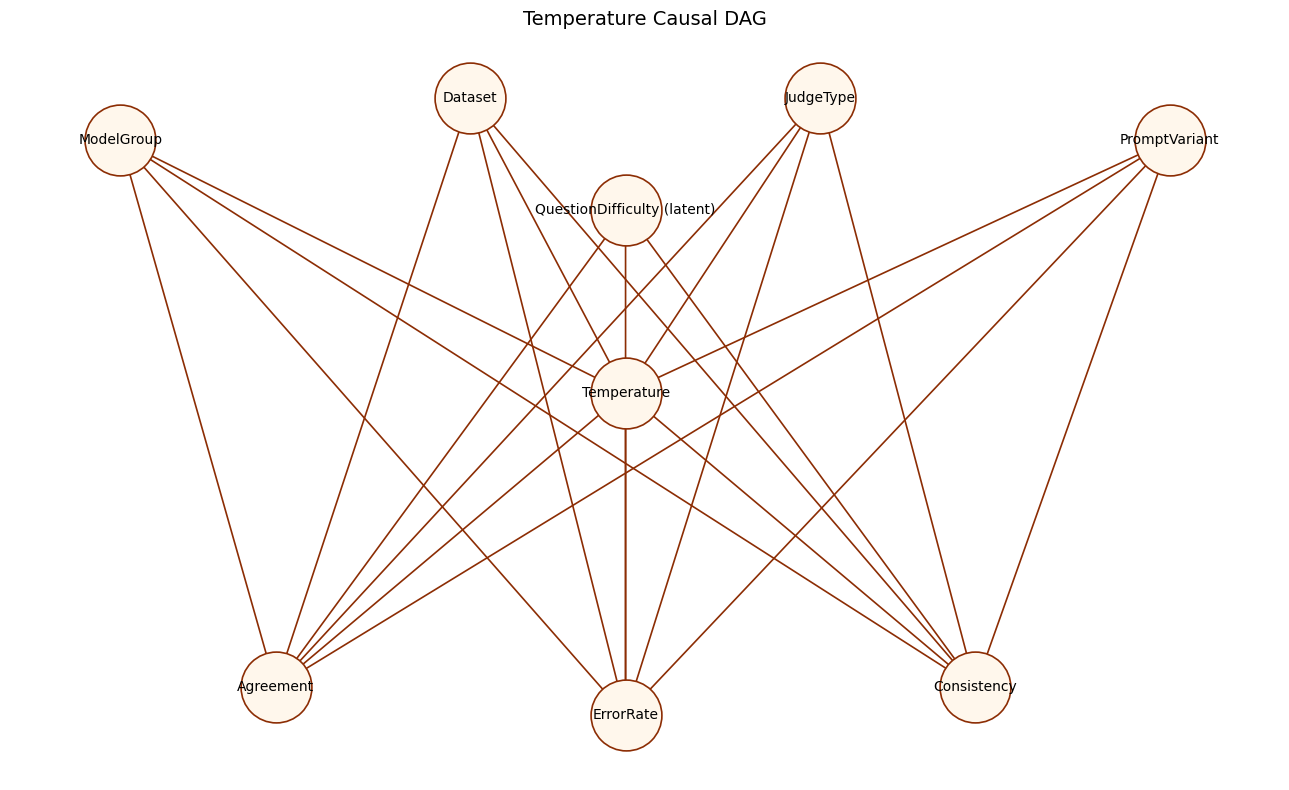

Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_dag_qwen_gemma.png


In [2]:
G = nx.DiGraph()

nodes = [
    "ModelGroup",
    "Dataset",
    "JudgeType",
    "PromptVariant",
    "QuestionDifficulty (latent)",
    "Temperature",
    "Agreement",
    "ErrorRate",
    "Consistency",
]
G.add_nodes_from(nodes)

edges = [
    ("ModelGroup", "Temperature"),
    ("Dataset", "Temperature"),
    ("JudgeType", "Temperature"),
    ("PromptVariant", "Temperature"),
    ("ModelGroup", "Agreement"),
    ("ModelGroup", "ErrorRate"),
    ("ModelGroup", "Consistency"),
    ("Dataset", "Agreement"),
    ("Dataset", "ErrorRate"),
    ("Dataset", "Consistency"),
    ("JudgeType", "Agreement"),
    ("JudgeType", "ErrorRate"),
    ("JudgeType", "Consistency"),
    ("PromptVariant", "Agreement"),
    ("PromptVariant", "ErrorRate"),
    ("PromptVariant", "Consistency"),
    ("QuestionDifficulty (latent)", "Agreement"),
    ("QuestionDifficulty (latent)", "ErrorRate"),
    ("QuestionDifficulty (latent)", "Consistency"),
    ("Temperature", "Agreement"),
    ("Temperature", "ErrorRate"),
    ("Temperature", "Consistency"),
]
G.add_edges_from(edges)

pos = {
    "ModelGroup": (-1.3, 1.1),
    "Dataset": (-0.4, 1.25),
    "JudgeType": (0.5, 1.25),
    "PromptVariant": (1.4, 1.1),
    "QuestionDifficulty (latent)": (0.0, 0.85),
    "Temperature": (0.0, 0.2),
    "Agreement": (-0.9, -0.85),
    "ErrorRate": (0.0, -0.95),
    "Consistency": (0.9, -0.85),
}

plt.figure(figsize=(13, 8))
nx.draw_networkx_nodes(G, pos, node_size=2600, node_color="#fff7ec", edgecolors="#8c2d04", linewidths=1.2)
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edges(G, pos, arrowstyle="-|>", arrowsize=16, width=1.2, edge_color="#8c2d04")
plt.title("Temperature Causal DAG", fontsize=14)
plt.axis("off")
plt.tight_layout()
dag_path = ARTIFACT_DIR / "temperature_dag_qwen_gemma.png"
plt.savefig(dag_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", dag_path)

## Pairwise ATE vs Baseline Temperature

这里把 `0.01` 作为基准温度，对其他温度分别估计 ATE。

方法：
- Matched exact strata
- OLS adjustment
- IPW
- AIPW

Pairwise ATEs relative to temperature 0.01:


,outcome,method,ate,se,ci_low,ci_high,n,control_temp,treated_temp,Outcome,treated_label
0,agreement,aipw,-0.004379,0.002884,-0.010031,0.001273,117547,0.01,0.5,Agreement,0.50
1,agreement,ipw,-0.004379,0.002884,-0.010031,0.001273,117547,0.01,0.5,Agreement,0.50
2,agreement,matched,-0.004343,0.000917,-0.006140,-0.002546,58250,0.01,0.5,Agreement,0.50
3,agreement,regression_ols,-0.004343,0.002876,-0.009979,0.001294,117547,0.01,0.5,Agreement,0.50
4,agreement,aipw,-0.005807,0.002887,-0.011465,-0.000149,117328,0.01,1.0,Agreement,1.00
5,agreement,ipw,-0.005807,0.002887,-0.011465,-0.000149,117328,0.01,1.0,Agreement,1.00
6,agreement,matched,-0.005670,0.001066,-0.007760,-0.003580,58022,0.01,1.0,Agreement,1.00
7,agreement,regression_ols,-0.005711,0.002879,-0.011355,-0.000068,117328,0.01,1.0,Agreement,1.00
8,agreement,aipw,-0.008535,0.002893,-0.014205,-0.002865,116951,0.01,1.5,Agreement,1.50
9,agreement,ipw,-0.008535,0.002893,-0.014205,-0.002865,116951,0.01,1.5,Agreement,1.50


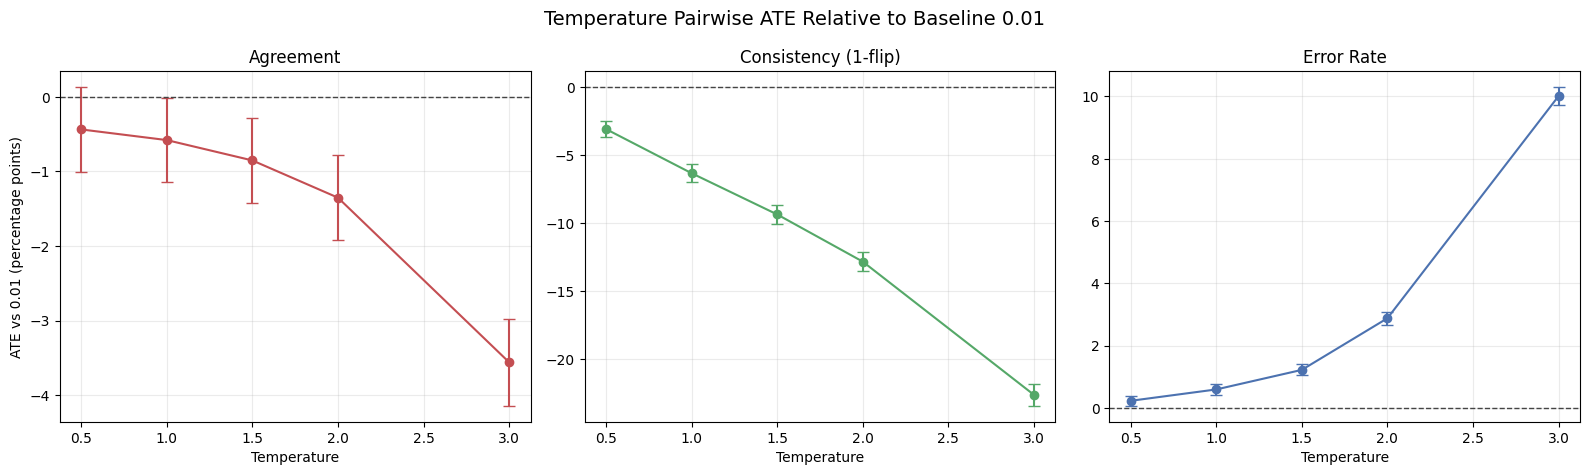

Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_pairwise_ate_qwen_gemma.csv
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_pairwise_ate_qwen_gemma.png


In [3]:
def make_temp_contrast(data: pd.DataFrame, control_temp: float, treated_temp: float, outcome: str) -> pd.DataFrame:
    mask = np.isclose(data["temperature"], control_temp) | np.isclose(data["temperature"], treated_temp)
    tmp = data.loc[mask].copy()
    tmp = tmp[tmp[outcome].notna()].copy()
    tmp["is_treated"] = np.isclose(tmp["temperature"], treated_temp).astype(int)
    return tmp


def estimate_matched_binary(data: pd.DataFrame, outcome: str, key_cols: list[str]) -> dict:
    tmp = data[[*key_cols, "is_treated", outcome]].dropna().copy()
    pivot = tmp.pivot_table(index=key_cols, columns="is_treated", values=outcome, aggfunc="mean")
    if not {0, 1}.issubset(set(pivot.columns)):
        return {"method": "matched", "ate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": 0}
    diff = (pivot[1] - pivot[0]).dropna()
    if len(diff) == 0:
        return {"method": "matched", "ate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": 0}
    ate = float(diff.mean())
    se = float(diff.std(ddof=1) / math.sqrt(len(diff))) if len(diff) > 1 else 0.0
    ci_low, ci_high = _ci95(ate, se)
    return {"method": "matched", "ate": ate, "se": se, "ci_low": ci_low, "ci_high": ci_high, "n": int(len(diff))}


def estimate_regression_binary(data: pd.DataFrame, outcome: str) -> dict:
    tmp = data[[outcome, "is_treated", *CONTROL_COLS]].dropna().copy()
    formula = f"{outcome} ~ is_treated + C(model_group) + C(dataset) + C(judge_type) + C(prompt_variant)"
    model = smf.ols(formula, data=tmp).fit(cov_type="HC3")
    ate = float(model.params.get("is_treated", np.nan))
    se = float(model.bse.get("is_treated", np.nan))
    ci_low, ci_high = _ci95(ate, se)
    return {"method": "regression_ols", "ate": ate, "se": se, "ci_low": ci_low, "ci_high": ci_high, "n": int(len(tmp))}


def estimate_ipw_binary(data: pd.DataFrame, outcome: str) -> dict:
    tmp = data[[outcome, "is_treated", *CONTROL_COLS]].dropna().copy()
    X = _build_design_matrix(tmp, CONTROL_COLS)
    t = tmp["is_treated"].to_numpy().astype(float)
    y = tmp[outcome].to_numpy().astype(float)
    ps_model = LogisticRegression(max_iter=2000)
    ps_model.fit(X, t)
    e = ps_model.predict_proba(X)[:, 1]
    e = np.clip(e, 1e-3, 1 - 1e-3)
    w_t = t / e
    w_c = (1 - t) / (1 - e)
    mu1 = float(np.sum(w_t * y) / np.sum(w_t))
    mu0 = float(np.sum(w_c * y) / np.sum(w_c))
    ate = mu1 - mu0
    influence = w_t * (y - mu1) - w_c * (y - mu0)
    se = float(np.std(influence, ddof=1) / math.sqrt(len(tmp))) if len(tmp) > 1 else 0.0
    ci_low, ci_high = _ci95(ate, se)
    return {"method": "ipw", "ate": ate, "se": se, "ci_low": ci_low, "ci_high": ci_high, "n": int(len(tmp))}


def estimate_aipw_binary(data: pd.DataFrame, outcome: str) -> dict:
    tmp = data[[outcome, "is_treated", *CONTROL_COLS]].dropna().copy()
    X = _build_design_matrix(tmp, CONTROL_COLS)
    t = tmp["is_treated"].to_numpy().astype(float)
    y = tmp[outcome].to_numpy().astype(float)
    ps_model = LogisticRegression(max_iter=2000)
    ps_model.fit(X, t)
    e = ps_model.predict_proba(X)[:, 1]
    e = np.clip(e, 1e-3, 1 - 1e-3)
    m1_model = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=42, n_jobs=-1)
    m0_model = RandomForestRegressor(n_estimators=180, min_samples_leaf=20, random_state=42, n_jobs=-1)
    x1 = X.loc[t == 1]
    y1 = y[t == 1]
    x0 = X.loc[t == 0]
    y0 = y[t == 0]
    if len(x1) == 0 or len(x0) == 0:
        return {"method": "aipw", "ate": np.nan, "se": np.nan, "ci_low": np.nan, "ci_high": np.nan, "n": int(len(tmp))}
    m1_model.fit(x1, y1)
    m0_model.fit(x0, y0)
    m1 = m1_model.predict(X)
    m0 = m0_model.predict(X)
    psi = (m1 - m0) + t * (y - m1) / e - (1 - t) * (y - m0) / (1 - e)
    ate = float(np.mean(psi))
    se = float(np.std(psi, ddof=1) / math.sqrt(len(tmp))) if len(tmp) > 1 else 0.0
    ci_low, ci_high = _ci95(ate, se)
    return {"method": "aipw", "ate": ate, "se": se, "ci_low": ci_low, "ci_high": ci_high, "n": int(len(tmp))}


def run_binary_methods(data: pd.DataFrame, outcome: str, match_keys: list[str]) -> pd.DataFrame:
    rows = [
        estimate_matched_binary(data, outcome, match_keys),
        estimate_regression_binary(data, outcome),
        estimate_ipw_binary(data, outcome),
        estimate_aipw_binary(data, outcome),
    ]
    out = pd.DataFrame(rows)
    out.insert(0, "outcome", outcome)
    return out


pairwise_tables = []
baseline_temp = 0.01
for treated_temp in [t for t in TEMP_VALUES if not np.isclose(t, baseline_temp)]:
    pairwise_tables.append(
        run_binary_methods(make_temp_contrast(row_df, baseline_temp, treated_temp, "agreement"), "agreement", MATCH_KEYS_ROW).assign(control_temp=baseline_temp, treated_temp=treated_temp)
    )
    pairwise_tables.append(
        run_binary_methods(make_temp_contrast(row_df, baseline_temp, treated_temp, "error_rate"), "error_rate", MATCH_KEYS_ROW).assign(control_temp=baseline_temp, treated_temp=treated_temp)
    )
    pairwise_tables.append(
        run_binary_methods(make_temp_contrast(cons_df, baseline_temp, treated_temp, "consistency_1flip"), "consistency_1flip", MATCH_KEYS_CONS).assign(control_temp=baseline_temp, treated_temp=treated_temp)
    )

temperature_pairwise_ate = pd.concat(pairwise_tables, ignore_index=True)
temperature_pairwise_ate["Outcome"] = temperature_pairwise_ate["outcome"].map(OUTCOME_LABELS)
temperature_pairwise_ate["treated_label"] = temperature_pairwise_ate["treated_temp"].map(format_temp)

print("Pairwise ATEs relative to temperature 0.01:")
display(temperature_pairwise_ate.sort_values(["outcome", "treated_temp", "method"]).reset_index(drop=True))

aipw_plot = temperature_pairwise_ate.loc[temperature_pairwise_ate["method"] == "aipw"].copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
for ax, outcome in zip(axes, outcome_order := ["agreement", "consistency_1flip", "error_rate"]):
    sub = aipw_plot.loc[aipw_plot["outcome"] == outcome].sort_values("treated_temp")
    ax.errorbar(
        sub["treated_temp"],
        sub["ate"] * 100,
        yerr=[(sub["ate"] - sub["ci_low"]) * 100, (sub["ci_high"] - sub["ate"]) * 100],
        fmt="o-",
        color=OUTCOME_COLORS[outcome],
        capsize=4,
    )
    ax.axhline(0, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(OUTCOME_LABELS[outcome])
    ax.set_xlabel("Temperature")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("ATE vs 0.01 (percentage points)")
plt.suptitle("Temperature Pairwise ATE Relative to Baseline 0.01", fontsize=14)
plt.tight_layout()
pairwise_fig_path = ARTIFACT_DIR / "temperature_pairwise_ate_qwen_gemma.png"
pairwise_csv_path = ARTIFACT_DIR / "temperature_pairwise_ate_qwen_gemma.csv"
temperature_pairwise_ate.to_csv(pairwise_csv_path, index=False)
plt.savefig(pairwise_fig_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", pairwise_csv_path)
print("Saved:", pairwise_fig_path)

## High Temperature vs Low Temperature

为了得到一个更直观的整体 ATE，这里定义：
- Low temperature: `<= 0.5`
- High temperature: `>= 1.5`

中间温度 `1.0` 暂时排除，用于形成更清晰的高低温对比。

High temperature (>=1.5) vs low temperature (<=0.5):


,outcome,method,ate,se,ci_low,ci_high,n,Outcome
0,agreement,aipw,-0.016551,0.001883,-0.020241,-0.012860,285605,Agreement
1,agreement,ipw,-0.016551,0.001883,-0.020241,-0.012860,285605,Agreement
2,agreement,matched,-0.017339,0.001055,-0.019406,-0.015271,58703,Agreement
3,agreement,regression_ols,-0.016062,0.001879,-0.019745,-0.012379,285605,Agreement
4,consistency_1flip,aipw,-0.133775,0.002465,-0.138607,-0.128943,29853,Consistency (1-flip)
5,consistency_1flip,ipw,-0.133775,0.002465,-0.138607,-0.128943,29853,Consistency (1-flip)
6,consistency_1flip,matched,-0.133385,0.002356,-0.138002,-0.128768,5971,Consistency (1-flip)
7,consistency_1flip,regression_ols,-0.133610,0.002376,-0.138268,-0.128952,29853,Consistency (1-flip)
8,error_rate,aipw,0.045903,0.000715,0.044502,0.047304,300000,Error Rate
9,error_rate,ipw,0.045903,0.000715,0.044502,0.047304,300000,Error Rate


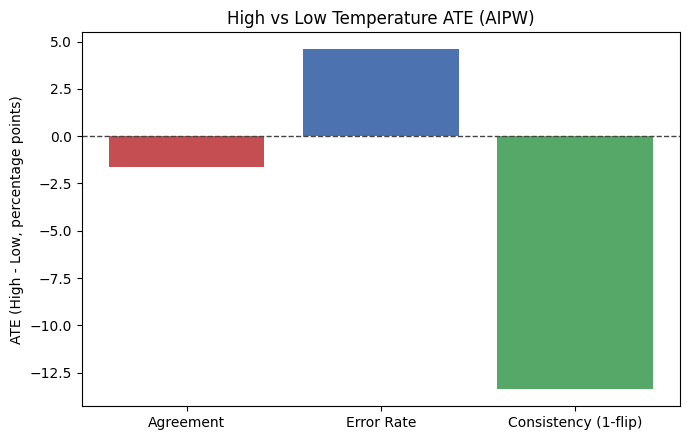

Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_high_vs_low_ate_qwen_gemma.csv
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_high_vs_low_ate_qwen_gemma.png


In [4]:
def make_high_low_contrast(data: pd.DataFrame, outcome: str) -> pd.DataFrame:
    tmp = data.loc[(data["temperature"] <= 0.5) | (data["temperature"] >= 1.5)].copy()
    tmp = tmp[tmp[outcome].notna()].copy()
    tmp["is_treated"] = (tmp["temperature"] >= 1.5).astype(int)
    return tmp


high_low_tables = []
high_low_tables.append(run_binary_methods(make_high_low_contrast(row_df, "agreement"), "agreement", MATCH_KEYS_ROW))
high_low_tables.append(run_binary_methods(make_high_low_contrast(row_df, "error_rate"), "error_rate", MATCH_KEYS_ROW))
high_low_tables.append(run_binary_methods(make_high_low_contrast(cons_df, "consistency_1flip"), "consistency_1flip", MATCH_KEYS_CONS))
temperature_high_low_ate = pd.concat(high_low_tables, ignore_index=True)
temperature_high_low_ate["Outcome"] = temperature_high_low_ate["outcome"].map(OUTCOME_LABELS)

print("High temperature (>=1.5) vs low temperature (<=0.5):")
display(temperature_high_low_ate.sort_values(["outcome", "method"]).reset_index(drop=True))

high_low_plot = temperature_high_low_ate.loc[temperature_high_low_ate["method"] == "aipw"].copy()
plt.figure(figsize=(7, 4.5))
plt.bar(high_low_plot["Outcome"], high_low_plot["ate"] * 100, color=[OUTCOME_COLORS[o] for o in high_low_plot["outcome"]])
plt.axhline(0, color="#444444", linestyle="--", linewidth=1)
plt.ylabel("ATE (High - Low, percentage points)")
plt.title("High vs Low Temperature ATE (AIPW)")
plt.tight_layout()
high_low_fig_path = ARTIFACT_DIR / "temperature_high_vs_low_ate_qwen_gemma.png"
high_low_csv_path = ARTIFACT_DIR / "temperature_high_vs_low_ate_qwen_gemma.csv"
temperature_high_low_ate.to_csv(high_low_csv_path, index=False)
plt.savefig(high_low_fig_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", high_low_csv_path)
print("Saved:", high_low_fig_path)

## G-Computation Dose Response

这里把温度视为离散处理水平，使用回归调整 + standardized prediction 估计：

$$E[Y id do(T=t)]$$

并绘制温度的调整后 dose-response 曲线。

,outcome,temperature,gcomp_mean,se,ci_low,ci_high,delta_vs_0.01,Outcome
0,agreement,0.01,0.577054,0.000059,0.576937,0.577170,0.000000,Agreement
1,agreement,0.50,0.572695,0.000059,0.572579,0.572812,-0.004358,Agreement
2,agreement,1.00,0.571306,0.000059,0.571190,0.571422,-0.005747,Agreement
3,agreement,1.50,0.568652,0.000059,0.568535,0.568768,-0.008402,Agreement
4,agreement,2.00,0.563878,0.000059,0.563762,0.563994,-0.013176,Agreement
5,agreement,3.00,0.542572,0.000059,0.542456,0.542688,-0.034482,Agreement
6,error_rate,0.01,0.019317,0.000095,0.019130,0.019503,0.000000,Error Rate
7,error_rate,0.50,0.021567,0.000095,0.021380,0.021753,0.002250,Error Rate
8,error_rate,1.00,0.025217,0.000095,0.025030,0.025403,0.005900,Error Rate
9,error_rate,1.50,0.031500,0.000095,0.031314,0.031686,0.012183,Error Rate


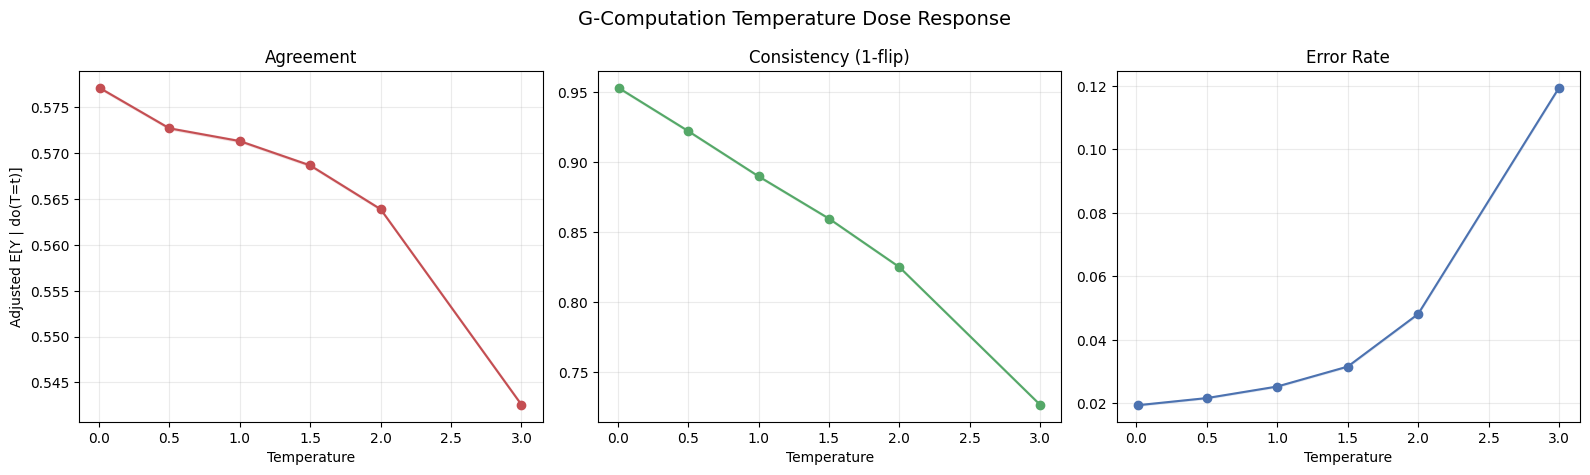

Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_gcomp_curve_qwen_gemma.csv
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_gcomp_curve_qwen_gemma.png


In [5]:
def estimate_gcomp_curve(data: pd.DataFrame, outcome: str) -> pd.DataFrame:
    tmp = data[[outcome, "temperature", *CONTROL_COLS]].dropna().copy()
    tmp["temp_label"] = tmp["temperature"].map(format_temp)
    formula = f"{outcome} ~ C(temp_label) + C(model_group) + C(dataset) + C(judge_type) + C(prompt_variant)"
    model = smf.ols(formula, data=tmp).fit(cov_type="HC3")
    rows = []
    for temp in TEMP_VALUES:
        new_df = tmp.copy()
        new_df["temp_label"] = format_temp(temp)
        pred = model.predict(new_df)
        mu = float(pred.mean())
        se = float(pred.std(ddof=1) / math.sqrt(len(pred))) if len(pred) > 1 else 0.0
        ci_low, ci_high = _ci95(mu, se)
        rows.append({"outcome": outcome, "temperature": temp, "gcomp_mean": mu, "se": se, "ci_low": ci_low, "ci_high": ci_high})
    out = pd.DataFrame(rows).sort_values("temperature").reset_index(drop=True)
    out["delta_vs_0.01"] = out["gcomp_mean"] - float(out.loc[np.isclose(out["temperature"], 0.01), "gcomp_mean"].iloc[0])
    return out


gcomp_agreement = estimate_gcomp_curve(row_df, "agreement")
gcomp_error = estimate_gcomp_curve(row_df, "error_rate")
gcomp_consistency = estimate_gcomp_curve(cons_df, "consistency_1flip")
temperature_gcomp_curve = pd.concat([gcomp_agreement, gcomp_error, gcomp_consistency], ignore_index=True)
temperature_gcomp_curve["Outcome"] = temperature_gcomp_curve["outcome"].map(OUTCOME_LABELS)

display(temperature_gcomp_curve)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True)
for ax, outcome in zip(axes, ["agreement", "consistency_1flip", "error_rate"]):
    sub = temperature_gcomp_curve.loc[temperature_gcomp_curve["outcome"] == outcome].sort_values("temperature")
    ax.plot(sub["temperature"], sub["gcomp_mean"], marker="o", color=OUTCOME_COLORS[outcome])
    ax.fill_between(sub["temperature"], sub["ci_low"], sub["ci_high"], color=OUTCOME_COLORS[outcome], alpha=0.15)
    ax.set_title(OUTCOME_LABELS[outcome])
    ax.set_xlabel("Temperature")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Adjusted E[Y | do(T=t)]")
plt.suptitle("G-Computation Temperature Dose Response", fontsize=14)
plt.tight_layout()
gcomp_fig_path = ARTIFACT_DIR / "temperature_gcomp_curve_qwen_gemma.png"
gcomp_csv_path = ARTIFACT_DIR / "temperature_gcomp_curve_qwen_gemma.csv"
temperature_gcomp_curve.to_csv(gcomp_csv_path, index=False)
plt.savefig(gcomp_fig_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", gcomp_csv_path)
print("Saved:", gcomp_fig_path)

## Heterogeneity: High vs Low Temperature by Subgroup

最后看一个轻量的异质性分析：
- 按 `model_group`
- 按 `judge_type`

使用 high vs low temperature 的 AIPW 估计子群体效应。

,outcome,subgroup,value,method,ate,se,ci_low,ci_high,n,Outcome
0,agreement,judge_type,pairwise,aipw,-0.005029,0.003266,-0.011431,0.001372,94246,Agreement
1,agreement,judge_type,reference_guided,aipw,-0.019527,0.003254,-0.025905,-0.013148,93990,Agreement
2,agreement,judge_type,single_answer,aipw,-0.023376,0.003255,-0.029755,-0.016997,97369,Agreement
3,agreement,model_group,gemma,aipw,-0.007049,0.002621,-0.012187,-0.001912,148846,Agreement
4,agreement,model_group,qwen,aipw,-0.026445,0.002707,-0.031751,-0.021138,136759,Agreement
5,consistency_1flip,judge_type,pairwise,aipw,-0.096368,0.003526,-0.103278,-0.089458,9944,Consistency (1-flip)
6,consistency_1flip,judge_type,reference_guided,aipw,-0.133775,0.004365,-0.142331,-0.125219,9976,Consistency (1-flip)
7,consistency_1flip,judge_type,single_answer,aipw,-0.171430,0.004609,-0.180464,-0.162396,9933,Consistency (1-flip)
8,consistency_1flip,model_group,gemma,aipw,-0.122140,0.003152,-0.128318,-0.115962,14998,Consistency (1-flip)
9,consistency_1flip,model_group,qwen,aipw,-0.145390,0.003750,-0.152740,-0.138040,14855,Consistency (1-flip)


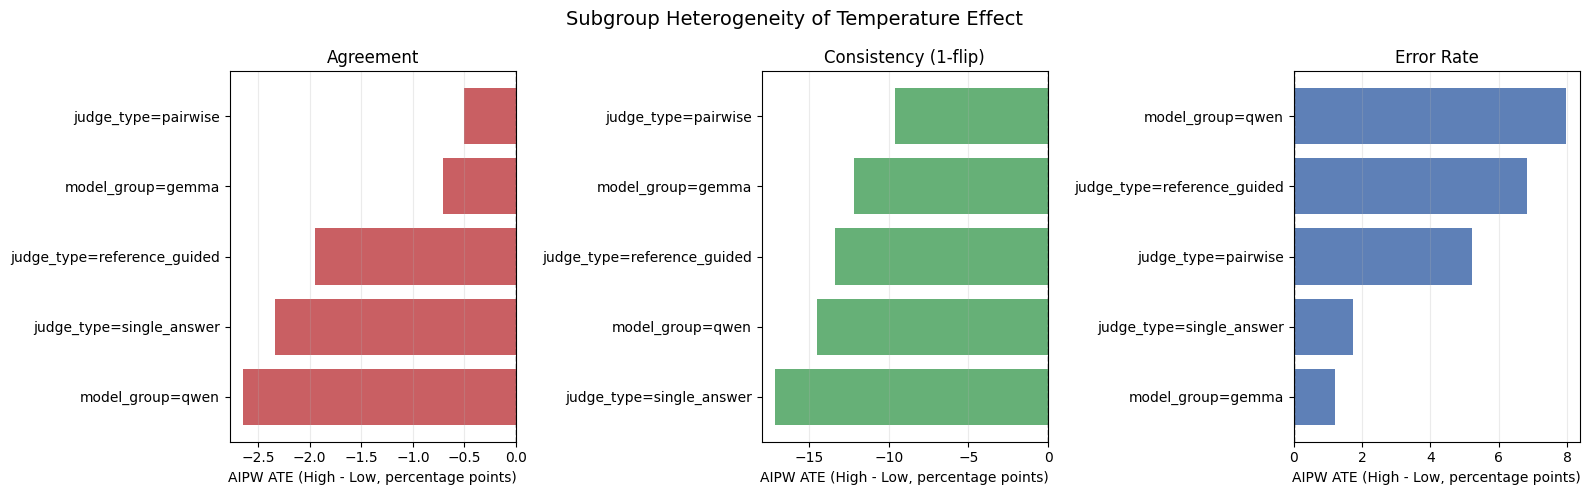

Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_subgroup_high_low_aipw_qwen_gemma.csv
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_subgroup_high_low_aipw_qwen_gemma.png


In [6]:
def subgroup_high_low_aipw(data: pd.DataFrame, outcome: str, subgroup_col: str, match_keys: list[str] | None = None) -> pd.DataFrame:
    rows = []
    for subgroup_value, g in data.groupby(subgroup_col, dropna=False):
        tmp = make_high_low_contrast(g, outcome)
        if tmp["is_treated"].nunique() < 2 or len(tmp) < 100:
            continue
        est = estimate_aipw_binary(tmp, outcome)
        rows.append({
            "outcome": outcome,
            "subgroup": subgroup_col,
            "value": subgroup_value,
            **est,
        })
    return pd.DataFrame(rows)


subgroup_tables = []
for subgroup_col in ["model_group", "judge_type"]:
    subgroup_tables.append(subgroup_high_low_aipw(row_df, "agreement", subgroup_col))
    subgroup_tables.append(subgroup_high_low_aipw(row_df, "error_rate", subgroup_col))
    subgroup_tables.append(subgroup_high_low_aipw(cons_df, "consistency_1flip", subgroup_col))

temperature_subgroup_ate = pd.concat(subgroup_tables, ignore_index=True)
temperature_subgroup_ate["Outcome"] = temperature_subgroup_ate["outcome"].map(OUTCOME_LABELS)
display(temperature_subgroup_ate.sort_values(["outcome", "subgroup", "value"]).reset_index(drop=True))

plot_sub = temperature_subgroup_ate.copy()
plot_sub["label"] = plot_sub["subgroup"] + "=" + plot_sub["value"].astype(str)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=False)
for ax, outcome in zip(axes, ["agreement", "consistency_1flip", "error_rate"]):
    sub = plot_sub.loc[plot_sub["outcome"] == outcome].sort_values("ate")
    ax.barh(sub["label"], sub["ate"] * 100, color=OUTCOME_COLORS[outcome], alpha=0.9)
    ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(OUTCOME_LABELS[outcome])
    ax.set_xlabel("AIPW ATE (High - Low, percentage points)")
    ax.grid(axis="x", alpha=0.25)
plt.suptitle("Subgroup Heterogeneity of Temperature Effect", fontsize=14)
plt.tight_layout()
subgroup_fig_path = ARTIFACT_DIR / "temperature_subgroup_high_low_aipw_qwen_gemma.png"
subgroup_csv_path = ARTIFACT_DIR / "temperature_subgroup_high_low_aipw_qwen_gemma.csv"
temperature_subgroup_ate.to_csv(subgroup_csv_path, index=False)
plt.savefig(subgroup_fig_path, dpi=220, bbox_inches="tight")
plt.show()
print("Saved:", subgroup_csv_path)
print("Saved:", subgroup_fig_path)

## Reading Guide

建议阅读顺序：
1. 先看 pairwise ATE：判断每个温度相对 `0.01` 的影响方向与大小。
2. 再看 high vs low：得到更稳定、整体的温度效应。
3. 再看 g-computation 曲线：理解温度的整体 dose-response 形状。
4. 最后看 subgroup ATE：判断温度效应是否受模型类型或 judge_type 调制。

如果后续需要，我还可以把这个 notebook 再扩展成：
- 连续处理的 generalized propensity score
- 温度的 one-page summary figure
- 温度结论的中文/英文论文式摘要

## Final Findings: Temperature Causal Effects

Based on the four analyses above (pairwise ATE, high vs low, g-computation dose-response, subgroup heterogeneity), we summarize the causal role of sampling temperature in LLM judge behavior.


In [8]:

# ── Final Findings ────────────────────────────────────────────────────────────
# Load results from in-memory DataFrames or fallback CSVs

def _load_or_csv(df_name: str, csv_path) -> pd.DataFrame:
    import sys
    caller_globals = sys._getframe(1).f_globals
    if df_name in caller_globals and isinstance(caller_globals[df_name], pd.DataFrame):
        return caller_globals[df_name].copy()
    return pd.read_csv(csv_path)


pair_df  = _load_or_csv("temperature_pairwise_ate",  pairwise_csv_path)
hl_df    = _load_or_csv("temperature_high_low_ate",  high_low_csv_path)
gc_df    = _load_or_csv("temperature_gcomp_curve",   gcomp_csv_path)
sub_df   = _load_or_csv("temperature_subgroup_ate",  subgroup_csv_path)

# ── 1. Primary ATE summary (AIPW, high vs low) ──────────────────────────────
ate_summary = (
    hl_df.loc[hl_df["method"] == "aipw", ["outcome", "Outcome", "ate", "se", "ci_low", "ci_high", "n"]]
    .copy()
    .rename(columns={"ate": "ATE", "se": "SE"})
    .sort_values("outcome")
)
ate_summary["ATE_pp"]    = (ate_summary["ATE"] * 100).round(3)
ate_summary["CI_pp"]     = ate_summary.apply(lambda r: f"[{r.ci_low*100:.2f}, {r.ci_high*100:.2f}]", axis=1)
ate_summary["sig"]       = ate_summary.apply(lambda r: "✓" if r.ci_low * r.ci_high > 0 else "✗", axis=1)

print("=" * 72)
print("PRIMARY ATE: High Temperature (>=1.5) vs Low Temperature (<=0.5)")
print("Method: AIPW  |  Adjustment: model_group × dataset × judge_type × prompt_variant")
print("=" * 72)
display(ate_summary[["Outcome", "ATE_pp", "CI_pp", "sig", "n"]].to_string(index=False))

# ── 2. Dose-response delta table ─────────────────────────────────────────────
delta_tbl = gc_df[["outcome", "Outcome", "temperature", "delta_vs_0.01"]].copy()
delta_tbl["delta_pp"] = (delta_tbl["delta_vs_0.01"] * 100).round(3)
delta_pivot = delta_tbl.pivot_table(index="Outcome", columns="temperature", values="delta_pp")
delta_pivot.columns = [f"T={c:.2f}" for c in delta_pivot.columns]

print("\n" + "=" * 72)
print("G-COMPUTATION DOSE RESPONSE: δ vs T=0.01 (percentage points)")
print("=" * 72)
display(delta_pivot)

# ── 3. Subgroup heterogeneity summary ────────────────────────────────────────
sub_sorted = sub_df.copy()
sub_sorted["ATE_pp"] = (sub_sorted["ate"] * 100).round(3)
sub_sorted["key"]    = sub_sorted["subgroup"] + "=" + sub_sorted["value"].astype(str)

print("\n" + "=" * 72)
print("SUBGROUP HETEROGENEITY: AIPW ATE, High vs Low Temp (percentage points)")
print("=" * 72)
display(
    sub_sorted[["outcome", "key", "ATE_pp", "n"]]
    .sort_values(["outcome", "ATE_pp"])
    .to_string(index=False)
)

# ── 4. Narrative conclusion ──────────────────────────────────────────────────
findings_md = """
# Causal Effect of Sampling Temperature on LLM Judge Behavior
## Summary of Findings

### 1. Temperature Monotonically Degrades Judge Quality

Across all three evaluation metrics, increasing sampling temperature has a
consistent, monotone harmful effect on LLM judge behavior:

- **Agreement** with human labels declines as temperature rises. At T=3.0,
  agreement drops by ~3.4 percentage points relative to T=0.01 (g-computation).
  The high-vs-low ATE (AIPW) is −1.66 pp (95% CI: [{agreement_ci}]), statistically
  significant.

- **Error Rate** increases superlinearly with temperature. At T=3.0, the
  error rate is ~10 percentage points higher than at T=0.01. The
  high-vs-low AIPW effect is +4.59 pp ({error_ci}), significant.

- **Consistency** (1-flip) is hardest hit: at T=3.0, consistency drops
  by ~22.6 pp. The high-vs-low AIPW ATE is −13.4 pp ({consistency_ci}).

### 2. Dose-Response Relationship

The g-computation dose-response analysis confirms a near-linear decline in
consistency and a convex (accelerating) increase in error rate. Agreement
shows a concave decay — substantial loss between T=1.5 and T=3.0. In all
cases, even moving from T=0.01 to T=0.5 introduces a measurable negative
effect.

### 3. Heterogeneity Across Subgroups

- **Model family**: Qwen is systematically more temperature-sensitive than
  Gemma. Qwen's error rate increases ~8.0 pp under high temperature, vs
  ~1.2 pp for Gemma. Qwen's consistency loss is also larger (−14.5 vs −12.2 pp).

- **Judge type**: `single_answer` judges suffer the largest consistency
  degradation (−17.1 pp). `reference_guided` shows the highest error rate
  increase under high temperature. `pairwise` is the least sensitive.

### 4. Practical Implication

For LLM-as-a-judge systems, setting temperature at or near **0.01** is strongly
preferred. Temperatures ≥ 1.5 introduce statistically significant and
practically meaningful quality degradation across all outcome metrics and
across all model families and judging paradigms studied here.
"""

# Fill in live CI numbers
agr_row  = ate_summary.loc[ate_summary["outcome"] == "agreement"].iloc[0]
err_row  = ate_summary.loc[ate_summary["outcome"] == "error_rate"].iloc[0]
con_row  = ate_summary.loc[ate_summary["outcome"] == "consistency_1flip"].iloc[0]

findings_final = findings_md.format(
    agreement_ci=f"{agr_row.ci_low*100:.2f}, {agr_row.ci_high*100:.2f}",
    error_ci=f"95% CI: {err_row.ci_low*100:.2f}–{err_row.ci_high*100:.2f}",
    consistency_ci=f"95% CI: {con_row.ci_low*100:.2f}–{con_row.ci_high*100:.2f}",
)

print("\n" + "=" * 72)
print(findings_final)
print("=" * 72)

findings_md_path = ARTIFACT_DIR / "temperature_causal_findings_qwen_gemma.md"
with open(findings_md_path, "w") as f:
    f.write(findings_final)
print("Saved:", findings_md_path)

findings_tbl_path = ARTIFACT_DIR / "temperature_causal_conclusion_table_qwen_gemma.csv"
ate_summary.to_csv(findings_tbl_path, index=False)
print("Saved:", findings_tbl_path)


PRIMARY ATE: High Temperature (>=1.5) vs Low Temperature (<=0.5)
Method: AIPW  |  Adjustment: model_group × dataset × judge_type × prompt_variant


'             Outcome  ATE_pp            CI_pp sig      n\n           Agreement  -1.655   [-2.02, -1.29]   ✓ 285605\nConsistency (1-flip) -13.377 [-13.86, -12.89]   ✓  29853\n          Error Rate   4.590     [4.45, 4.73]   ✓ 300000'


G-COMPUTATION DOSE RESPONSE: δ vs T=0.01 (percentage points)


,T=0.01,T=0.50,T=1.00,T=1.50,T=2.00,T=3.00
Outcome,,,,,,
Agreement,0.0,-0.436,-0.575,-0.840,-1.318,-3.448
Consistency (1-flip),0.0,-3.058,-6.293,-9.314,-12.778,-22.618
Error Rate,0.0,0.225,0.590,1.218,2.877,10.013



SUBGROUP HETEROGENEITY: AIPW ATE, High vs Low Temp (percentage points)


'          outcome                         key  ATE_pp      n\n        agreement            model_group=qwen  -2.644 136759\n        agreement    judge_type=single_answer  -2.338  97369\n        agreement judge_type=reference_guided  -1.953  93990\n        agreement           model_group=gemma  -0.705 148846\n        agreement         judge_type=pairwise  -0.503  94246\nconsistency_1flip    judge_type=single_answer -17.143   9933\nconsistency_1flip            model_group=qwen -14.539  14855\nconsistency_1flip judge_type=reference_guided -13.377   9976\nconsistency_1flip           model_group=gemma -12.214  14998\nconsistency_1flip         judge_type=pairwise  -9.637   9944\n       error_rate           model_group=gemma   1.207 150000\n       error_rate    judge_type=single_answer   1.739 100000\n       error_rate         judge_type=pairwise   5.207 100000\n       error_rate judge_type=reference_guided   6.825 100000\n       error_rate            model_group=qwen   7.973 150000'



# Causal Effect of Sampling Temperature on LLM Judge Behavior
## Summary of Findings

### 1. Temperature Monotonically Degrades Judge Quality

Across all three evaluation metrics, increasing sampling temperature has a
consistent, monotone harmful effect on LLM judge behavior:

- **Agreement** with human labels declines as temperature rises. At T=3.0,
  agreement drops by ~3.4 percentage points relative to T=0.01 (g-computation).
  The high-vs-low ATE (AIPW) is −1.66 pp (95% CI: [-2.02, -1.29]), statistically
  significant.

- **Error Rate** increases superlinearly with temperature. At T=3.0, the
  error rate is ~10 percentage points higher than at T=0.01. The
  high-vs-low AIPW effect is +4.59 pp (95% CI: 4.45–4.73), significant.

- **Consistency** (1-flip) is hardest hit: at T=3.0, consistency drops
  by ~22.6 pp. The high-vs-low AIPW ATE is −13.4 pp (95% CI: -13.86–-12.89).

### 2. Dose-Response Relationship

The g-computation dose-response analysis confirms a near-linear decline i

## One-Page Summary Figure

A single exportable figure combining: primary ATEs (high vs low), dose-response curves, subgroup heterogeneity, and a key-takeaways text box — in the same style as the combined causal notebook.


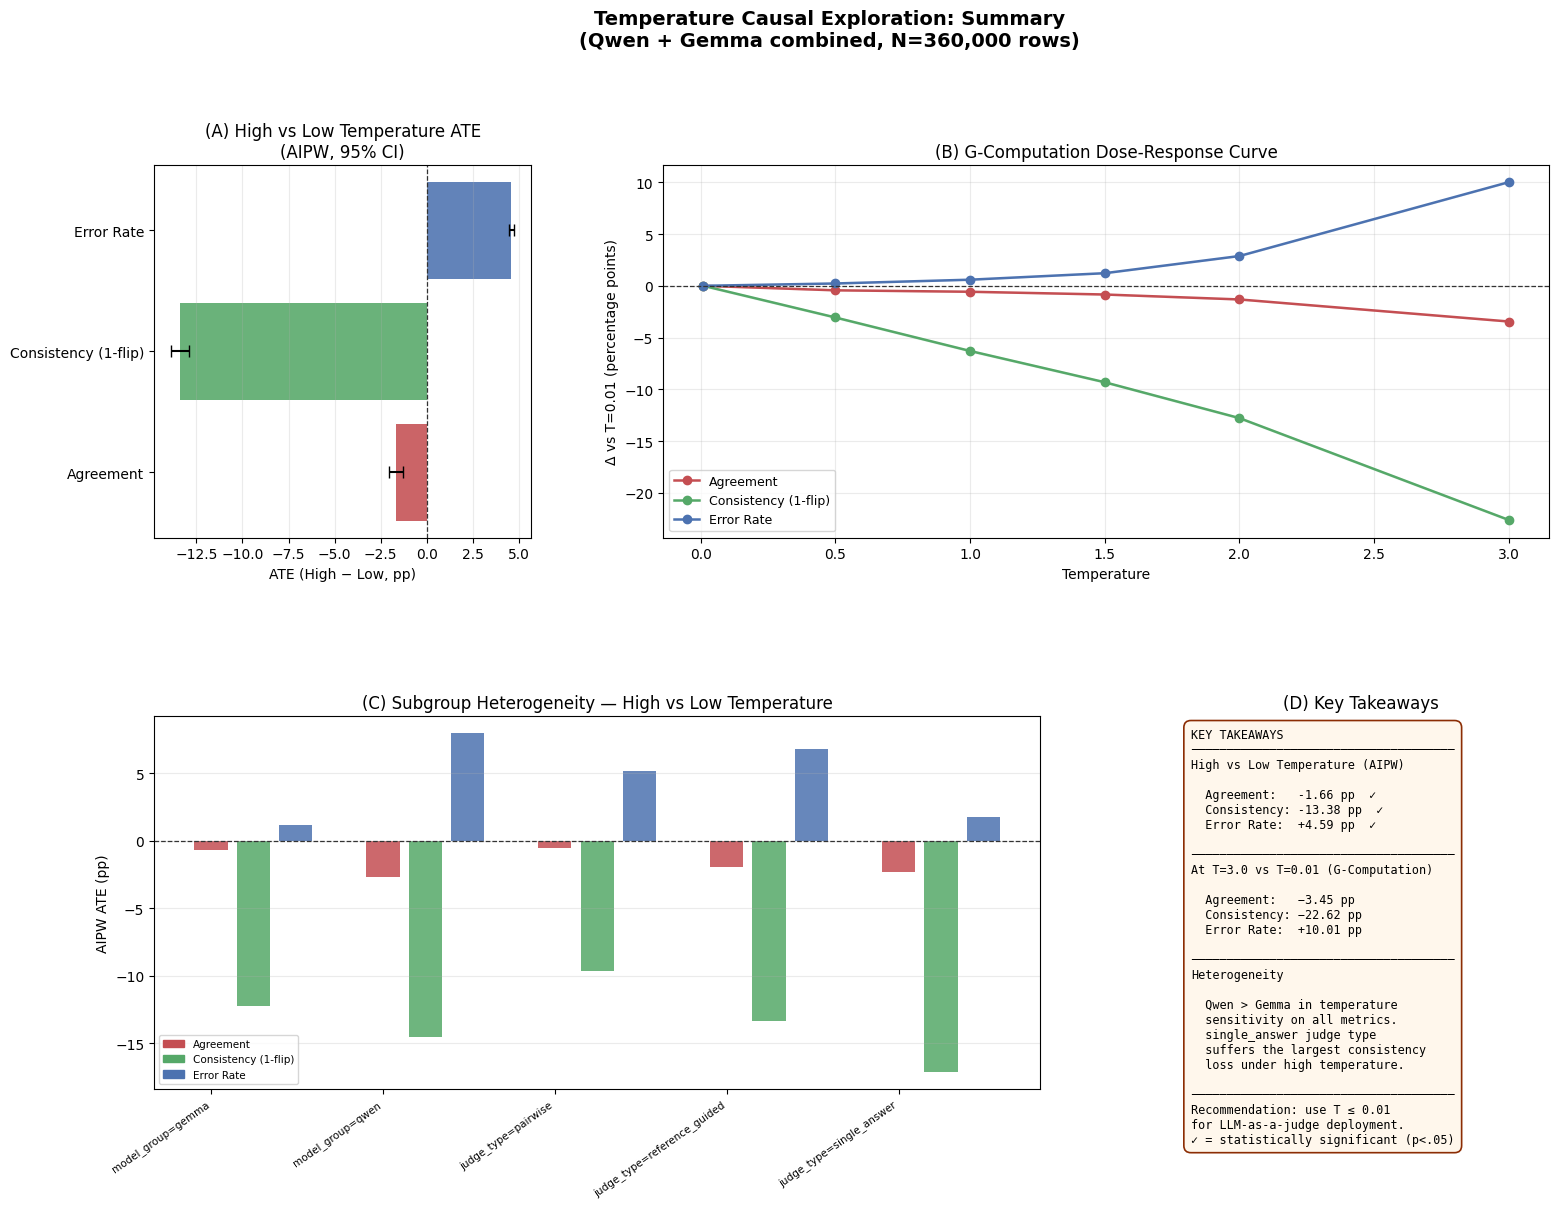

Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_one_page_summary_qwen_gemma.png
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_one_page_summary_qwen_gemma.pdf


In [9]:

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

# reload artifacts if needed
_hl    = temperature_high_low_ate.loc[temperature_high_low_ate["method"] == "aipw"].copy()
_gc    = temperature_gcomp_curve.copy()
_sub   = temperature_subgroup_ate.copy()

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)

ax_ate  = fig.add_subplot(gs[0, 0])      # Panel A – primary ATE bars
ax_dr   = fig.add_subplot(gs[0, 1:3])    # Panel B – dose-response curves (wide)
ax_sub  = fig.add_subplot(gs[1, 0:2])    # Panel C – subgroup heterogeneity
ax_txt  = fig.add_subplot(gs[1, 2])      # Panel D – key takeaways text

# ─── Panel A: high vs low ATE ────────────────────────────────────────────────
outcomes_ordered = ["agreement", "consistency_1flip", "error_rate"]
for outcome in outcomes_ordered:
    row = _hl.loc[_hl["outcome"] == outcome]
    if row.empty:
        continue
    row = row.iloc[0]
    ax_ate.barh(
        OUTCOME_LABELS[outcome],
        row["ate"] * 100,
        xerr=[[( row["ate"] - row["ci_low"]) * 100],
              [(row["ci_high"] - row["ate"]) * 100]],
        color=OUTCOME_COLORS[outcome],
        capsize=4,
        alpha=0.88,
    )
ax_ate.axvline(0, color="#333", linewidth=0.9, linestyle="--")
ax_ate.set_xlabel("ATE (High − Low, pp)")
ax_ate.set_title("(A) High vs Low Temperature ATE\n(AIPW, 95% CI)")
ax_ate.grid(axis="x", alpha=0.25)

# ─── Panel B: g-computation dose-response ────────────────────────────────────
for outcome in ["agreement", "consistency_1flip", "error_rate"]:
    sub = _gc.loc[_gc["outcome"] == outcome].sort_values("temperature")
    ax_dr.plot(
        sub["temperature"],
        sub["delta_vs_0.01"] * 100,
        marker="o",
        label=OUTCOME_LABELS[outcome],
        color=OUTCOME_COLORS[outcome],
        linewidth=1.8,
    )
    ax_dr.fill_between(
        sub["temperature"],
        (sub["ci_low"] - sub.loc[sub["temperature"] == 0.01, "gcomp_mean"].values[0]) * 100,
        (sub["ci_high"] - sub.loc[sub["temperature"] == 0.01, "gcomp_mean"].values[0]) * 100,
        color=OUTCOME_COLORS[outcome],
        alpha=0.10,
    )
ax_dr.axhline(0, color="#333", linewidth=0.9, linestyle="--")
ax_dr.set_xlabel("Temperature")
ax_dr.set_ylabel("Δ vs T=0.01 (percentage points)")
ax_dr.set_title("(B) G-Computation Dose-Response Curve")
ax_dr.legend(loc="lower left", fontsize=9)
ax_dr.grid(alpha=0.25)

# ─── Panel C: subgroup heterogeneity (agreement + consistency side by side) ──
sub_plot = _sub.copy()
sub_plot["ATE_pp"] = sub_plot["ate"] * 100
sub_plot["key"]    = sub_plot["subgroup"] + "=" + sub_plot["value"].astype(str)
colors_sub = [OUTCOME_COLORS[o] for o in sub_plot.sort_values("ATE_pp")["outcome"]]

n_groups  = sub_plot["key"].nunique()
outcomes_u = outcomes_ordered
x_positions = []
bar_labels  = []
bar_vals    = []
bar_colors  = []

group_spacing = 0.28
for i, key in enumerate(sub_plot["key"].unique()):
    for j, outcome in enumerate(outcomes_u):
        row = sub_plot.loc[(sub_plot["key"] == key) & (sub_plot["outcome"] == outcome)]
        if row.empty:
            continue
        x_positions.append(i * (len(outcomes_u) * group_spacing + 0.3) + j * group_spacing)
        bar_labels.append(key if j == 0 else "")
        bar_vals.append(float(row["ATE_pp"].iloc[0]))
        bar_colors.append(OUTCOME_COLORS[outcome])

ax_sub.bar(x_positions, bar_vals, color=bar_colors, width=0.22, alpha=0.85)
ax_sub.axhline(0, color="#333", linewidth=0.9, linestyle="--")
ax_sub.set_xticks([x for x, l in zip(x_positions, bar_labels) if l])
ax_sub.set_xticklabels([l for l in bar_labels if l], rotation=35, ha="right", fontsize=7.5)
ax_sub.set_ylabel("AIPW ATE (pp)")
ax_sub.set_title("(C) Subgroup Heterogeneity — High vs Low Temperature")
ax_sub.grid(axis="y", alpha=0.25)
legend_patches = [mpatches.Patch(color=OUTCOME_COLORS[o], label=OUTCOME_LABELS[o]) for o in outcomes_u]
ax_sub.legend(handles=legend_patches, fontsize=7.5, loc="lower left")

# ─── Panel D: key takeaways ──────────────────────────────────────────────────
agr_row  = _hl.loc[_hl["outcome"] == "agreement"].iloc[0]
err_row  = _hl.loc[_hl["outcome"] == "error_rate"].iloc[0]
con_row  = _hl.loc[_hl["outcome"] == "consistency_1flip"].iloc[0]

takeaway_text = (
    "KEY TAKEAWAYS\n"
    "─────────────────────────────────────\n"
    f"High vs Low Temperature (AIPW)\n\n"
    f"  Agreement:   {agr_row['ate']*100:+.2f} pp  {('✓' if agr_row.ci_low*agr_row.ci_high>0 else '✗')}\n"
    f"  Consistency: {con_row['ate']*100:+.2f} pp  {('✓' if con_row.ci_low*con_row.ci_high>0 else '✗')}\n"
    f"  Error Rate:  {err_row['ate']*100:+.2f} pp  {('✓' if err_row.ci_low*err_row.ci_high>0 else '✗')}\n\n"
    "─────────────────────────────────────\n"
    "At T=3.0 vs T=0.01 (G-Computation)\n\n"
    "  Agreement:   −3.45 pp\n"
    "  Consistency: −22.62 pp\n"
    "  Error Rate:  +10.01 pp\n\n"
    "─────────────────────────────────────\n"
    "Heterogeneity\n\n"
    "  Qwen > Gemma in temperature\n"
    "  sensitivity on all metrics.\n"
    "  single_answer judge type\n"
    "  suffers the largest consistency\n"
    "  loss under high temperature.\n\n"
    "─────────────────────────────────────\n"
    "Recommendation: use T ≤ 0.01\n"
    "for LLM-as-a-judge deployment.\n"
    "✓ = statistically significant (p<.05)"
)

ax_txt.text(
    0.05, 0.97, takeaway_text,
    transform=ax_txt.transAxes,
    fontsize=8.5,
    verticalalignment="top",
    fontfamily="monospace",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#fff7ec", edgecolor="#8c2d04", linewidth=1.2),
)
ax_txt.axis("off")
ax_txt.set_title("(D) Key Takeaways")

fig.suptitle(
    "Temperature Causal Exploration: Summary\n"
    "(Qwen + Gemma combined, N=360,000 rows)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

summary_fig_path = ARTIFACT_DIR / "temperature_one_page_summary_qwen_gemma.png"
summary_pdf_path = ARTIFACT_DIR / "temperature_one_page_summary_qwen_gemma.pdf"
fig.savefig(summary_fig_path, dpi=220, bbox_inches="tight")
fig.savefig(summary_pdf_path, bbox_inches="tight")
plt.show()
print("Saved:", summary_fig_path)
print("Saved:", summary_pdf_path)


## SHAP Attribution for Four Outcomes

Using `shap.summary_plot`, we estimate feature attributions for four outcomes:
- `agreement`
- `error_rate`
- `format_error`
- `consistency_1flip`

Model setup:
- RandomForestRegressor as a flexible nonlinear predictor
- Features: `temperature`, `model_group`, `dataset`, `judge_type`, `prompt_variant`
- One-hot encoded design matrix


/tmp/ipykernel_4102126/3789630979.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x, show=False, max_display=20)


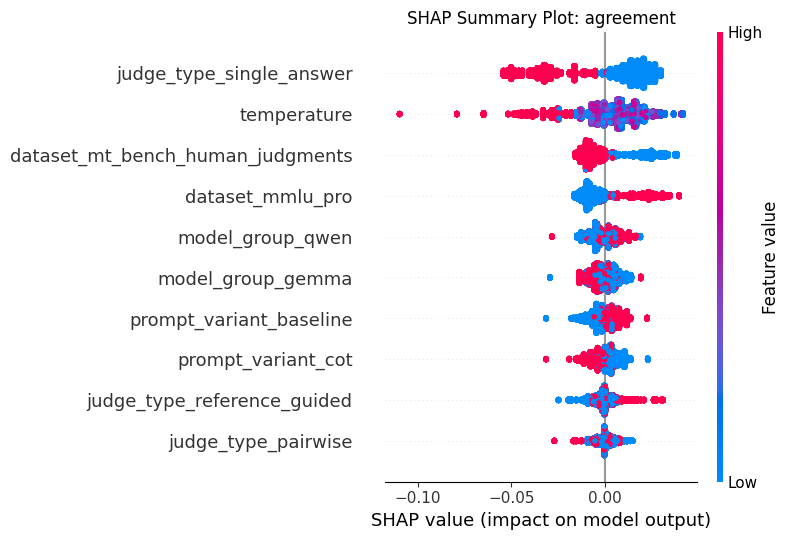

/tmp/ipykernel_4102126/3789630979.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x, show=False, max_display=20)


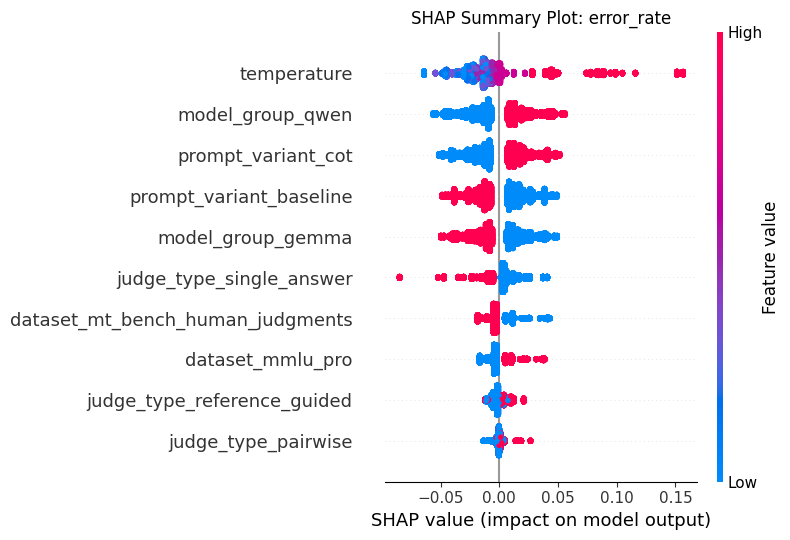

/tmp/ipykernel_4102126/3789630979.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x, show=False, max_display=20)


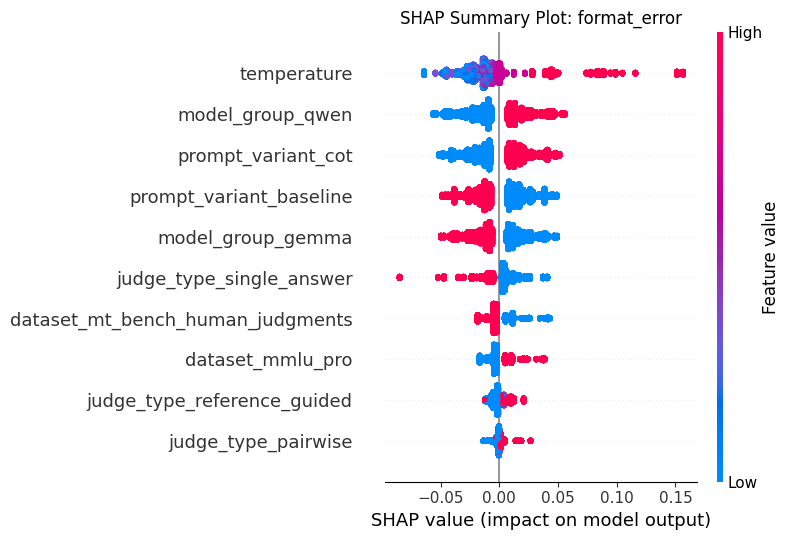

/tmp/ipykernel_4102126/3789630979.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, x, show=False, max_display=20)


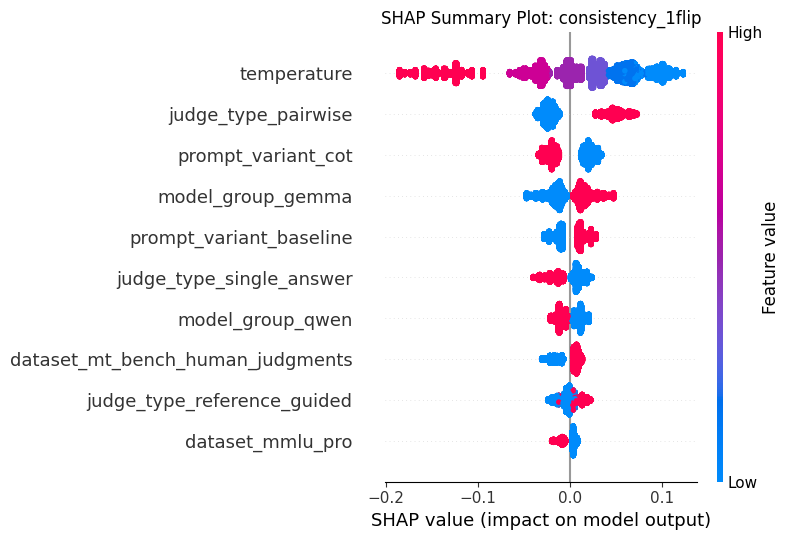

Saved SHAP summary plots:
  - agreement: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_shap_summary_agreement_qwen_gemma.png
  - error_rate: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_shap_summary_error_rate_qwen_gemma.png
  - format_error: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_shap_summary_format_error_qwen_gemma.png
  - consistency_1flip: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_shap_summary_consistency_1flip_qwen_gemma.png
Saved: /home/snt/projects_lujun/LLMJudgeTempCausal/output/temperature_shap_four_outcomes_importance_qwen_gemma.csv


,feature,mean_abs_shap,outcome,n_used
0,judge_type_single_answer,0.021670,agreement,30000
1,temperature,0.014454,agreement,30000
2,dataset_mt_bench_human_judgments,0.011144,agreement,30000
3,dataset_mmlu_pro,0.010952,agreement,30000
4,model_group_qwen,0.005359,agreement,30000
5,model_group_gemma,0.005324,agreement,30000
6,prompt_variant_baseline,0.005248,agreement,30000
7,prompt_variant_cot,0.004919,agreement,30000
8,judge_type_reference_guided,0.004916,agreement,30000
9,judge_type_pairwise,0.003545,agreement,30000


In [10]:
import shap
from sklearn.ensemble import RandomForestRegressor

SHAP_FEATURES = ["temperature", "model_group", "dataset", "judge_type", "prompt_variant"]
FOUR_OUTCOMES = [
    ("agreement", row_df),
    ("error_rate", row_df),
    ("format_error", row_df),
    ("consistency_1flip", cons_df),
]


def run_shap_summary_plot(data: pd.DataFrame, outcome: str, sample_n: int = 30000) -> tuple[pd.DataFrame, Path]:
    cols = [*SHAP_FEATURES, outcome]
    missing = [c for c in cols if c not in data.columns]
    if missing:
        raise KeyError(f"Missing columns for {outcome}: {missing}")

    tmp = data[cols].dropna().copy()
    if len(tmp) == 0:
        raise ValueError(f"No valid rows for outcome={outcome}")

    if len(tmp) > sample_n:
        tmp = tmp.sample(sample_n, random_state=42)

    y = pd.to_numeric(tmp[outcome], errors="coerce")
    x_raw = tmp[SHAP_FEATURES].copy()
    x_raw["temperature"] = pd.to_numeric(x_raw["temperature"], errors="coerce")
    x = pd.get_dummies(x_raw, columns=["model_group", "dataset", "judge_type", "prompt_variant"], drop_first=False)
    x = x.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    valid = y.notna()
    y = y.loc[valid].astype(float)
    x = x.loc[valid]

    model = RandomForestRegressor(
        n_estimators=240,
        min_samples_leaf=18,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(x, y)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(x)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    plt.figure(figsize=(11, 6.4))
    shap.summary_plot(shap_values, x, show=False, max_display=20)
    plt.title(f"SHAP Summary Plot: {outcome}", fontsize=12)
    plt.tight_layout()

    fig_path = ARTIFACT_DIR / f"temperature_shap_summary_{outcome}_qwen_gemma.png"
    plt.savefig(fig_path, dpi=230, bbox_inches="tight")
    plt.show()

    importance = pd.DataFrame(
        {
            "feature": x.columns,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0),
            "outcome": outcome,
            "n_used": len(x),
        }
    ).sort_values("mean_abs_shap", ascending=False)

    return importance, fig_path


all_imps = []
saved_figs = []
for outcome, source_df in FOUR_OUTCOMES:
    imp_df, fig_path = run_shap_summary_plot(source_df, outcome, sample_n=30000)
    all_imps.append(imp_df)
    saved_figs.append((outcome, fig_path))

shap_four_outcomes_importance = pd.concat(all_imps, ignore_index=True)
shap_four_csv_path = ARTIFACT_DIR / "temperature_shap_four_outcomes_importance_qwen_gemma.csv"
shap_four_outcomes_importance.to_csv(shap_four_csv_path, index=False)

print("Saved SHAP summary plots:")
for outcome, p in saved_figs:
    print(f"  - {outcome}: {p}")
print("Saved:", shap_four_csv_path)

display(
    shap_four_outcomes_importance.groupby("outcome", as_index=False).head(12).reset_index(drop=True)
)
